# Install (if needed) and Import Libraries

In [633]:
# Installation of pysentiment2 to get access to Loughran-McDonald Dictionary
# !pip install pysentiment2
# !pip install matplotlib
# !pip install openpyxl    


import numpy as np
import pandas as pd
import pysentiment2 as ps

import ast
import nltk as nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Load the xlsx file and check the DataFrame

In [634]:
filename = "mda_processed_sample.xlsx"
data = pd.read_excel(filename, sheet_name="after_stopword_removal") # Use the sheet with stopwords removed
# data = pd.read_excel(filename) # Use the sheet with stopwords removed


data.head()

# INFO:
# - doc column contains the document name
# - sent_{x} contains the sentence; NOTE: Not all documents have the same number of sentences


,doc,sent_1,sent_2,sent_3,sent_4,sent_5,sent_6,sent_7,sent_8,sent_9,...,sent_442,sent_443,sent_444,sent_445,sent_446,sent_447,sent_448,sent_449,sent_450,sent_451
0,NVIDIA_10-K_2010-03-18_MDA.txt,"overview, helped, awaken, world, power, comput...","expertise, programmable, gpus, led, breakthrou...","serve, entertainment, consumer, market, geforc...","last, several, years, operated, reported, four...","however, effective, first_year, longer, separa...","gpu_business, comprised, primarily, geforce, p...","psb, comprised, quadro_professional, workstati...","mcp, business, reported, year, comprised, prim...","ion, family, products, addresses, integrated, ...",...,"although, number, units, estimate, impacted, i...","weak_diepackaging_material, combination, used,...","continue, seek, access, insurance, coverage, r...","however_assurance, made, aggregate, million, c...","september, october, november, several, putativ...","please, note, financial, information_regarding...","contractual_obligations, represents, unrecogni...","unable, reasonably_estimate, timing_potential,...","adoption_new, accounting, pronouncements, plea...","recently, issued, accounting, pronouncements, ..."
1,NVIDIA_10-K_2011-03-16_MDA.txt,"overview, invented, graphics, processing, unit...","since, strived, new, standards, visual_computi...","expertise, programmable, gpus, computer-system...","strategically, investing, three, major, areas,...","serve, visual_computing, market, consumer, gef...","three, primary, financial, gpu, professional_s...","years, operated, reported, four, major, produc...","however, first_year, began, reporting, interna...","comparative, periods, presented, reflect, change",...,"recommended, customers, consider, changing, th...","intend, fully, support, custom, ers, repair, r...","weak_diepackaging_material, combination, used,...","september, october, november, several, putativ...","please, note, financial, information_regarding...","contractual_obligations, represents, unrecogni...","unable, reasonably_estimate, timing_potential,...","adoption_new, accounting, pronouncements, plea...","recently, issued, accounting, pronouncements, ...",NaN
2,NVIDIA_10-K_2012-03-13_MDA.txt,"overview, known, millions, around, world, crea...","invention, gpu, brought, world, power, compute...","today, reach, well, beyond, pc_graphics","energy-efficient, processors, power, broad, ra...","mobile, processors, used, cell, phones, tablet...","pc, gamers, rely, gpus, enjoy, visually, immer...","designers, use, create, visual, effects, movie...","researchers, utilize, gpus, push, frontiers, s...","nearly, patents, granted, pending, worldwide, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NVIDIA_10-K_2013-03-12_MDA.txt,"overview, visual_computing, connecting, people...","world, increasingly, filled, visual, displays,...","visualization, transcends, cultural, language,...","long, known, millions, around, world, creating...","invention, gpu, introduced, world, power, prog...","today, reach, well, beyond, pc_graphics, games","energy-efficient, processors, heart, products,...","pc, gamers, choose, gpus, name, enjoy, immersi...","tegra_processors, power, smartphones_tablets, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NVIDIA_10-K_2014-03-13_MDA.txt,"overview, visual_computing","world, increasingly, filled, visual, displays,...","strategy, world, leader, visual_computing","target, applications, major, computing_platfor...","target, markets, gaming, design, visualization...","deploy, business, models, believe, best, suite...","long, known, bringing, video, games, life, pc_...","invention, gpu, introduced, world, power, prog...","today, reach, well, beyond, pc_graphics, games",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Modify df so it returns 1 sentence per row, remove blank sentences as we don't need to do any analysis

In [635]:
# Split sentences into individual rows
golden_df = data.copy()
golden_df = data.melt(id_vars=["doc"], var_name="sentence_id", value_name="sentence")

golden_df.head() # temp check its done correctly

# SIMPLE PROCESSING
# Drop NaNs for rows with empty sentences
golden_df = golden_df.dropna(subset=["sentence"])
# In case there are sentences that are empty but not marked NaN
golden_df = golden_df[golden_df["sentence"].astype(str).str.strip() != ""]


# Ensure that the melted DF is still the same as the original DF
sentence_cols = [col for col in data.columns if col.startswith("sent_")]
mask = data[sentence_cols].apply(lambda col: col.map(lambda x: pd.notna(x) and str(x).strip() != ""))
original_nonempty_count = mask.sum().sum()
long_count = golden_df.shape[0]

print("Original real sentence cells:", original_nonempty_count)
print("Rows in melted df:", long_count)
print("Match?", original_nonempty_count == long_count)

# Check
golden_df.head()



Original real sentence cells: 11881
Rows in melted df: 11881
Match? True


,doc,sentence_id,sentence
0,NVIDIA_10-K_2010-03-18_MDA.txt,sent_1,"overview, helped, awaken, world, power, comput..."
1,NVIDIA_10-K_2011-03-16_MDA.txt,sent_1,"overview, invented, graphics, processing, unit..."
2,NVIDIA_10-K_2012-03-13_MDA.txt,sent_1,"overview, known, millions, around, world, crea..."
3,NVIDIA_10-K_2013-03-12_MDA.txt,sent_1,"overview, visual_computing, connecting, people..."
4,NVIDIA_10-K_2014-03-13_MDA.txt,sent_1,"overview, visual_computing"


## Loughran-McDonald

### 1a. Start scoring each sentence (using LM)

NOTE: pysentiment2 is outdated as it still uses the 2018 dictionary! We will implement our own with the updated 2024 dictionary

In [636]:
# Initialise
lm = ps.LM()

# For a sentence, score using LM and return Positive, Negative, Polarity, Subjectivity
def analyse_lm(text):
    tokens = lm.tokenize(str(text))
    score = lm.get_score(tokens)
    return pd.Series({ # Return so we can append to each row in df
        "positive": score["Positive"],
        "negative": score["Negative"],
        "polarity": score["Polarity"],
        "subjectivity": score["Subjectivity"]
    })

def analyse_lm_test(text):
    tokens = lm.tokenize(str(text))
    return lm.get_score(tokens)



# NOTE:
# Positive number is the word counts for words in positive set
# Negative number is the word counts for words in negative set
# Polarity calculated with P-N/P+N (Overall Sentiment)
# Subjectivity = P+N/Total Tokens (How many of the tokens were sentiment-bearing words)

### 1b. Start scoring each sentence (using **UPDATED** LM2024)


In [637]:
lm_dict = pd.read_csv("Loughran-McDonald_MasterDictionary_1993-2024.csv")
print(lm_dict[["Word", "Positive", "Negative"]].tail())


positive_words = set(
    lm_dict.loc[lm_dict["Positive"] > 0, "Word"]
    .str.lower()
    .str.strip()
)

negative_words = set(
    lm_dict.loc[lm_dict["Negative"] > 0, "Word"]
    .str.lower()
    .str.strip()
)

print("Positive words:", len(positive_words))
print("Negative words:", len(negative_words))

            Word  Positive  Negative
86548     ZYGOTE         0         0
86549    ZYGOTES         0         0
86550    ZYGOTIC         0         0
86551  ZYMURGIES         0         0
86552    ZYMURGY         0         0
Positive words: 347
Negative words: 2345


In [638]:
# Sanity check...
if "able" in positive_words:
    print("ok")

if "absenteeism" in negative_words:
    print("ok2")

ok
ok2


In [639]:
# Creating functions for custom LM analyser

def tokenize_lm_text(text):
    return [t.strip().lower() for t in str(text).split(",") if t.strip() != ""]


def analyse_lm_CUSTOM(text):
    tokens = tokenize_lm_text(text)
    
    if len(tokens) == 0:
        return pd.Series({
            "positive": 0.0,
            "negative": 0.0,
            "polarity": 0.0,
            "subjectivity": 0.0
        })
    
    pos_count = sum(token in positive_words for token in tokens)
    neg_count = sum(token in negative_words for token in tokens)
    token_count = len(tokens)
    
    positive = pos_count / token_count
    negative = neg_count / token_count
    
    if (pos_count + neg_count) == 0:
        polarity = 0.0
        subjectivity = 0.0
    else:
        polarity = (pos_count - neg_count) / (pos_count + neg_count)
        subjectivity = (pos_count + neg_count) / token_count
    
    return pd.Series({
        "positive": positive,
        "negative": negative,
        "polarity": polarity,
        "subjectivity": subjectivity
    })


def analyse_lm_CUSTOMTEST(text):
    tokens = tokenize_lm_text(text)
    
    if len(tokens) == 0:
        return pd.Series({
            "positive": 0.0,
            "negative": 0.0,
            "polarity": 0.0,
            "subjectivity": 0.0
        })
    
    pos_count = sum(token in positive_words for token in tokens)
    neg_count = sum(token in negative_words for token in tokens)
    token_count = len(tokens)
    
    positive = pos_count / token_count
    negative = neg_count / token_count
    
    if (pos_count + neg_count) == 0:
        polarity = 0.0
        subjectivity = 0.0
    else:
        polarity = (pos_count - neg_count) / (pos_count + neg_count)
        subjectivity = (pos_count + neg_count) / token_count
    
    return {
        "Positive": positive,
        "Negative": negative,
        "Polarity": polarity,
        "Subjectivity": subjectivity
    }

#### Actually do the scoring HERE **PLEASE PAY ATTENTION HERE PLEASE**

In [640]:
# Make a copy
df = golden_df.copy()

# Feed each sentence to function, get the result
# scores = df["sentence"].apply(analyse_lm) # USING pysentiment2
scores = df["sentence"].apply(analyse_lm_CUSTOM) # USING CUSTOM


# Combine scores to each row
df = pd.concat([df, scores], axis=1)


In [641]:
# Add sentence sentiment label
def label_sentiment(p):
    if p > 0:
        return "positive"
    elif p < 0:
        return "negative"
    else:
        return "neutral"

df["sentence_sentiment"] = df["polarity"].apply(label_sentiment) # Positive polarity is more positive words than negative

df.head()

,doc,sentence_id,sentence,positive,negative,polarity,subjectivity,sentence_sentiment
0,NVIDIA_10-K_2010-03-18_MDA.txt,sent_1,"overview, helped, awaken, world, power, comput...",0.090909,0.0,1.0,0.090909,positive
1,NVIDIA_10-K_2011-03-16_MDA.txt,sent_1,"overview, invented, graphics, processing, unit...",0.166667,0.0,1.0,0.166667,positive
2,NVIDIA_10-K_2012-03-13_MDA.txt,sent_1,"overview, known, millions, around, world, crea...",0.000000,0.0,0.0,0.000000,neutral
3,NVIDIA_10-K_2013-03-12_MDA.txt,sent_1,"overview, visual_computing, connecting, people...",0.000000,0.0,0.0,0.000000,neutral
4,NVIDIA_10-K_2014-03-13_MDA.txt,sent_1,"overview, visual_computing",0.000000,0.0,0.0,0.000000,neutral


In [642]:
# JUST IN CASE, randomly check 5 rows to ensure that the calculations are done correctly and appended

import random
random_numbers_unique = random.sample(range(0, len(df)), 5)


for num in random_numbers_unique:
    print(f"Checking row {num}")
    temp_sent = df.iloc[num]["sentence"]
    # temp_result = analyse_lm_test(temp_sent)
    temp_result = analyse_lm_CUSTOMTEST(temp_sent)


    print(temp_result)
    
    # Compare results with the appended one
    appended = {
        "Positive": df.iloc[num]["positive"],
        "Negative": df.iloc[num]["negative"],
        "Polarity": df.iloc[num]["polarity"],
        "Subjectivity": df.iloc[num]["subjectivity"]
    }
    print(appended)

    print("positive match:", temp_result["Positive"] == appended["Positive"])
    print("negative match:", temp_result["Negative"] == appended["Negative"])
    print("polarity match:", temp_result["Polarity"] == appended["Polarity"])
    print("subjectivity match:", temp_result["Subjectivity"] == appended["Subjectivity"])
    



Checking row 9197
{'Positive': 0.0, 'Negative': 0.0, 'Polarity': 0.0, 'Subjectivity': 0.0}
{'Positive': np.float64(0.0), 'Negative': np.float64(0.0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
positive match: True
negative match: True
polarity match: True
subjectivity match: True
Checking row 7313
{'Positive': 0.0, 'Negative': 0.0, 'Polarity': 0.0, 'Subjectivity': 0.0}
{'Positive': np.float64(0.0), 'Negative': np.float64(0.0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
positive match: True
negative match: True
polarity match: True
subjectivity match: True
Checking row 5791
{'Positive': 0.0, 'Negative': 0.0, 'Polarity': 0.0, 'Subjectivity': 0.0}
{'Positive': np.float64(0.0), 'Negative': np.float64(0.0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
positive match: True
negative match: True
polarity match: True
subjectivity match: True
Checking row 64
{'Positive': 0.08333333333333333, 'Negative': 0.0, 'Polarity': 1.0, 'Subjectivity': 

### 2. Aggregate into each document for sentiment analysis

In [643]:
doc_summary = df.groupby("doc").agg(
    num_sentences=("sentence", "count"),
    total_positive=("positive", "sum"),
    total_negative=("negative", "sum"),
    avg_polarity=("polarity", "mean"),
    avg_subjectivity=("subjectivity", "mean")
).reset_index()

doc_summary["net_sentiment"] = (
    doc_summary["total_positive"] - doc_summary["total_negative"]
)

doc_summary.head()


,doc,num_sentences,total_positive,total_negative,avg_polarity,avg_subjectivity,net_sentiment
0,NVIDIA_10-K_2010-03-18_MDA.txt,450,2.570316,17.782904,-0.256000,0.045229,-15.212588
1,NVIDIA_10-K_2011-03-16_MDA.txt,448,3.680020,15.038114,-0.214732,0.041782,-11.358094
2,NVIDIA_10-K_2012-03-13_MDA.txt,410,5.287097,11.425985,-0.124228,0.040764,-6.138889
3,NVIDIA_10-K_2013-03-12_MDA.txt,400,4.466361,10.276565,-0.108000,0.036857,-5.810204
4,NVIDIA_10-K_2014-03-13_MDA.txt,376,3.914591,7.727240,-0.073404,0.030962,-3.812650


In [644]:
# Add counts of positive/negative sentences
sentiment_counts = df.pivot_table(
    index="doc",
    columns="sentence_sentiment",
    values="sentence",
    aggfunc="count",
    fill_value=0
).reset_index()

sentiment_counts = sentiment_counts.rename(columns={
    "positive": "num_positive_sentences",
    "negative": "num_negative_sentences",
    "neutral": "num_neutral_sentences"
})

doc_summary = doc_summary.merge(sentiment_counts, on="doc", how="left")

In [645]:
# Check it is properly added
doc_summary.head()

,doc,num_sentences,total_positive,total_negative,avg_polarity,avg_subjectivity,net_sentiment,num_negative_sentences,num_neutral_sentences,num_positive_sentences
0,NVIDIA_10-K_2010-03-18_MDA.txt,450,2.570316,17.782904,-0.256000,0.045229,-15.212588,142,285,23
1,NVIDIA_10-K_2011-03-16_MDA.txt,448,3.680020,15.038114,-0.214732,0.041782,-11.358094,126,294,28
2,NVIDIA_10-K_2012-03-13_MDA.txt,410,5.287097,11.425985,-0.124228,0.040764,-6.138889,95,273,42
3,NVIDIA_10-K_2013-03-12_MDA.txt,400,4.466361,10.276565,-0.108000,0.036857,-5.810204,82,281,37
4,NVIDIA_10-K_2014-03-13_MDA.txt,376,3.914591,7.727240,-0.073404,0.030962,-3.812650,64,277,35


In [646]:
# Again, check that it matches the original data df in terms of sentences

sentence_cols = [col for col in data.columns if col.startswith("sent_")]

original_counts = data.copy()

original_counts["original_num_sentences"] = data[sentence_cols].apply(
    lambda row: sum(pd.notna(x) and str(x).strip() != "" for x in row),
    axis=1
)

original_counts = original_counts[["doc", "original_num_sentences"]]

check_df = original_counts.merge(
    doc_summary[["doc", "num_sentences"]],
    on="doc",
    how="inner"
)

check_df["match"] = (
    check_df["original_num_sentences"] == check_df["num_sentences"]
)

print(check_df.tail())
print("All match?", check_df["match"].all())

mismatches = check_df[check_df["match"] == False]
print(mismatches)

                               doc  original_num_sentences  num_sentences  \
59  NVIDIA_10-Q_2024-08-28_MDA.txt                     172            172   
60  NVIDIA_10-Q_2024-11-20_MDA.txt                     150            150   
61  NVIDIA_10-Q_2025-05-28_MDA.txt                     131            131   
62  NVIDIA_10-Q_2025-08-27_MDA.txt                     136            136   
63  NVIDIA_10-Q_2025-11-19_MDA.txt                     140            140   

    match  
59   True  
60   True  
61   True  
62   True  
63   True  
All match? True
Empty DataFrame
Columns: [doc, original_num_sentences, num_sentences, match]
Index: []


### 3. Do some cool visualisations (for LM)

In [647]:
# Import libraries
import matplotlib.pyplot as plt

In [648]:
# Need to extract out the date and document type first

doc_summary["date"] = doc_summary["doc"].str.extract(r"(\d{4}-\d{2}-\d{2})")
doc_summary["date"] = pd.to_datetime(doc_summary["date"])
doc_summary["filing_type"] = doc_summary["doc"].str.extract(r"(10-K|10-Q)")


In [649]:
doc_summary.head()
print(doc_summary["filing_type"].value_counts())

filing_type
10-Q    48
10-K    16
Name: count, dtype: int64


In [650]:
# Sort by 10-K and 10-Q
df_10k = doc_summary[doc_summary["filing_type"] == "10-K"].copy()
df_10k = df_10k.sort_values("date")
print("10-K Rows:", df_10k.shape[0])

df_10q = doc_summary[doc_summary["filing_type"] == "10-Q"].copy()
df_10q = df_10q.sort_values("date")
print("10-Q Rows:", df_10q.shape[0])



10-K Rows: 16
10-Q Rows: 48


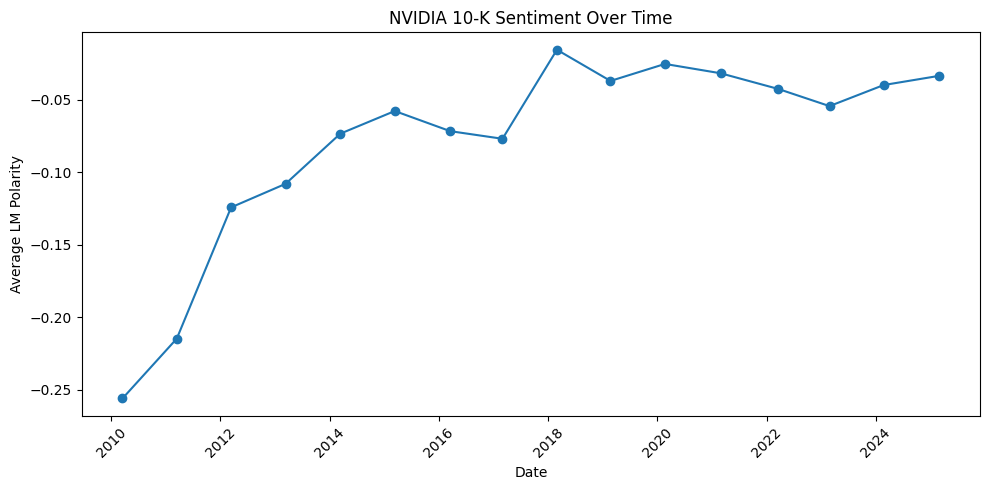

In [651]:
# Plot by 10-K
plt.figure(figsize=(10, 5))
plt.plot(df_10k["date"], df_10k["avg_polarity"], marker="o")
plt.xlabel("Date")
plt.ylabel("Average LM Polarity")
plt.title("NVIDIA 10-K Sentiment Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Higher polarity means more positive language

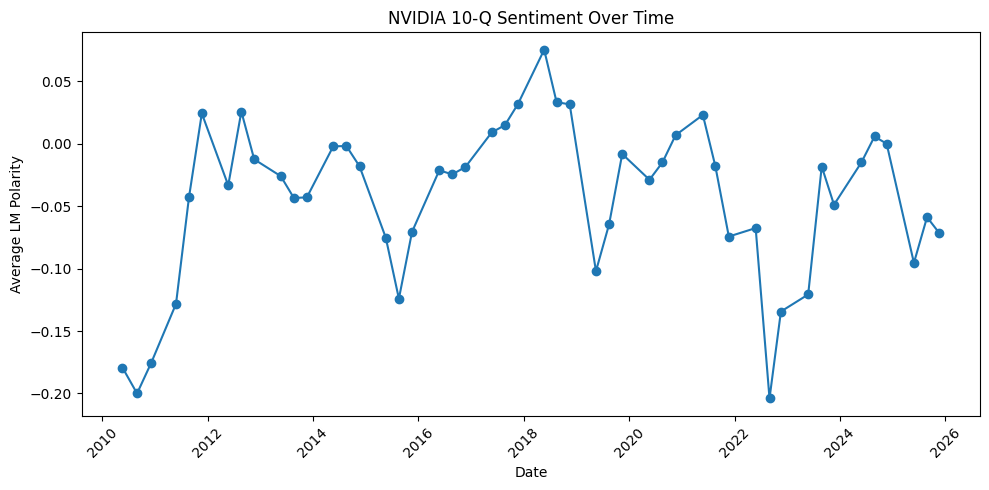

In [652]:
# Plot by 10-Q
plt.figure(figsize=(10, 5))
plt.plot(df_10q["date"], df_10q["avg_polarity"], marker="o")
plt.xlabel("Date")
plt.ylabel("Average LM Polarity")
plt.title("NVIDIA 10-Q Sentiment Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Higher polarity means more positive language

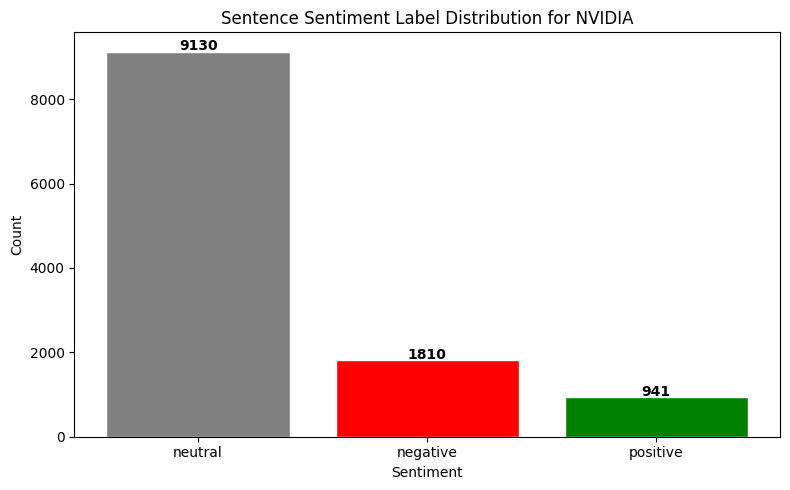

In [653]:
# Show total 

palette = {
    "positive": "green",
    "negative": "red",
    "neutral": "gray"
}

vc_plot = df["sentence_sentiment"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(
    vc_plot.index,
    vc_plot.values,
    color=[palette[label] for label in vc_plot.index],
    edgecolor="white"
)

plt.title("Sentence Sentiment Label Distribution for NVIDIA")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for i, (label, count) in enumerate(vc_plot.items()):
    plt.text(i, count + 30, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


## VADER

One issue is that VADER works on the original sentences, not tokenized and preprocessed data. So the results would already be limited

**Because the original natural sentence structure was not fully preserved, VADER results should be interpreted cautiously.**

In [654]:
vader_data_df = data.copy()

vader_data_df.head() # Should be golden copy as we did not touch the original df

vader_df = golden_df.copy()

vader_df.tail()


,doc,sentence_id,sentence
28672,NVIDIA_10-K_2010-03-18_MDA.txt,sent_449,"unable, reasonably_estimate, timing_potential,..."
28673,NVIDIA_10-K_2011-03-16_MDA.txt,sent_449,"adoption_new, accounting, pronouncements, plea..."
28736,NVIDIA_10-K_2010-03-18_MDA.txt,sent_450,"adoption_new, accounting, pronouncements, plea..."
28737,NVIDIA_10-K_2011-03-16_MDA.txt,sent_450,"recently, issued, accounting, pronouncements, ..."
28800,NVIDIA_10-K_2010-03-18_MDA.txt,sent_451,"recently, issued, accounting, pronouncements, ..."


### 1. Try to fix sentences

In [655]:
def fix_token_string(text):
    tokens = [t.strip() for t in str(text).split(",")]
    tokens = [t for t in tokens if t != ""]
    return " ".join(tokens)

vader_df["vader_text"] = vader_df["sentence"].apply(fix_token_string)


vader_df.head()

,doc,sentence_id,sentence,vader_text
0,NVIDIA_10-K_2010-03-18_MDA.txt,sent_1,"overview, helped, awaken, world, power, comput...",overview helped awaken world power computer_gr...
1,NVIDIA_10-K_2011-03-16_MDA.txt,sent_1,"overview, invented, graphics, processing, unit...",overview invented graphics processing unit gpu
2,NVIDIA_10-K_2012-03-13_MDA.txt,sent_1,"overview, known, millions, around, world, crea...",overview known millions around world creating ...
3,NVIDIA_10-K_2013-03-12_MDA.txt,sent_1,"overview, visual_computing, connecting, people...",overview visual_computing connecting people po...
4,NVIDIA_10-K_2014-03-13_MDA.txt,sent_1,"overview, visual_computing",overview visual_computing


### 2. Creation of VADER function, label sentences

In [656]:
vader = SentimentIntensityAnalyzer()

def analyse_VADER(text):
    score = vader.polarity_scores(str(text))
    
    return pd.Series({"vader_neg": score["neg"], "vader_pos": score["pos"], "vader_neu": score["neu"], "vader_compound": score["compound"]})

In [657]:
vader_scores = vader_df["vader_text"].apply(analyse_VADER)
vader_df = pd.concat([vader_df, vader_scores], axis=1)


In [658]:
def label_vader(compound):
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

vader_df["vader_sentiment_label"] = vader_df["vader_compound"].apply(label_vader)

In [659]:
vader_df.head()

,doc,sentence_id,sentence,vader_text,vader_neg,vader_pos,vader_neu,vader_compound,vader_sentiment_label
0,NVIDIA_10-K_2010-03-18_MDA.txt,sent_1,"overview, helped, awaken, world, power, comput...",overview helped awaken world power computer_gr...,0.0,0.000,1.000,0.0000,neutral
1,NVIDIA_10-K_2011-03-16_MDA.txt,sent_1,"overview, invented, graphics, processing, unit...",overview invented graphics processing unit gpu,0.0,0.000,1.000,0.0000,neutral
2,NVIDIA_10-K_2012-03-13_MDA.txt,sent_1,"overview, known, millions, around, world, crea...",overview known millions around world creating ...,0.0,0.375,0.625,0.7783,positive
3,NVIDIA_10-K_2013-03-12_MDA.txt,sent_1,"overview, visual_computing, connecting, people...",overview visual_computing connecting people po...,0.0,0.318,0.682,0.4215,positive
4,NVIDIA_10-K_2014-03-13_MDA.txt,sent_1,"overview, visual_computing",overview visual_computing,0.0,0.000,1.000,0.0000,neutral


### 3. Aggregate into each document for sentiment analysis (again)

In [660]:
vader_doc_summary = vader_df.groupby("doc").agg(
    num_sentences=("sentence", "count"),
    avg_vader_neg=("vader_neg", "mean"),
    avg_vader_neu=("vader_neu", "mean"),
    avg_vader_pos=("vader_pos", "mean"),
    avg_vader_compound=("vader_compound", "mean")
).reset_index()

In [661]:
# Add sentence counts also

vader_counts = vader_df.pivot_table(
    index="doc",
    columns="vader_sentiment_label",
    values="sentence",
    aggfunc="count",
    fill_value=0
).reset_index()

vader_counts = vader_counts.rename(columns={
    "positive": "num_vader_positive_sentences",
    "negative": "num_vader_negative_sentences",
    "neutral": "num_vader_neutral_sentences"
})
vader_doc_summary = vader_doc_summary.merge(vader_counts, on="doc", how="left")


# Extract by date and 10-Q, 10-K

vader_doc_summary["date"] = vader_doc_summary["doc"].str.extract(r"(\d{4}-\d{2}-\d{2})")
vader_doc_summary["date"] = pd.to_datetime(vader_doc_summary["date"], errors="coerce")
vader_doc_summary["filing_type"] = vader_doc_summary["doc"].str.extract(r"(10-K|10-Q)")

In [662]:
vader_doc_summary.head()

,doc,num_sentences,avg_vader_neg,avg_vader_neu,avg_vader_pos,avg_vader_compound,num_vader_negative_sentences,num_vader_neutral_sentences,num_vader_positive_sentences,date,filing_type
0,NVIDIA_10-K_2010-03-18_MDA.txt,450,0.068740,0.803838,0.127436,0.102768,105,132,213,2010-03-18,10-K
1,NVIDIA_10-K_2011-03-16_MDA.txt,448,0.067819,0.795911,0.136254,0.110997,100,137,211,2011-03-16,10-K
2,NVIDIA_10-K_2012-03-13_MDA.txt,410,0.058844,0.791422,0.149727,0.148415,82,114,214,2012-03-13,10-K
3,NVIDIA_10-K_2013-03-12_MDA.txt,400,0.051705,0.809520,0.138785,0.144200,70,136,194,2013-03-12,10-K
4,NVIDIA_10-K_2014-03-13_MDA.txt,376,0.048125,0.810011,0.141864,0.153347,59,126,191,2014-03-13,10-K


### 4. Visualise VADER

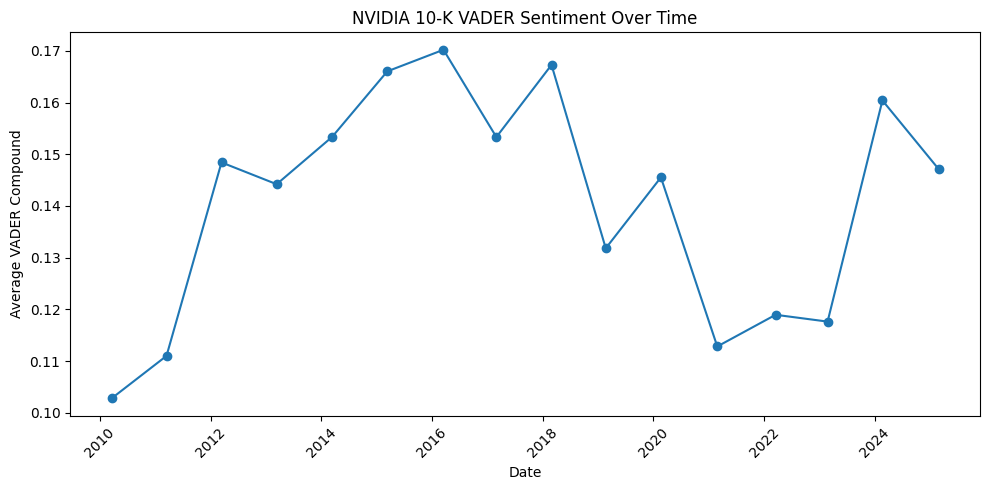

In [663]:
# 10-K

vader_10k = vader_doc_summary[vader_doc_summary["filing_type"] == "10-K"].copy()

plt.figure(figsize=(10, 5))
plt.plot(vader_10k["date"], vader_10k["avg_vader_compound"], marker="o")
plt.xlabel("Date")
plt.ylabel("Average VADER Compound")
plt.title("NVIDIA 10-K VADER Sentiment Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Higher means that document is more positive in tone

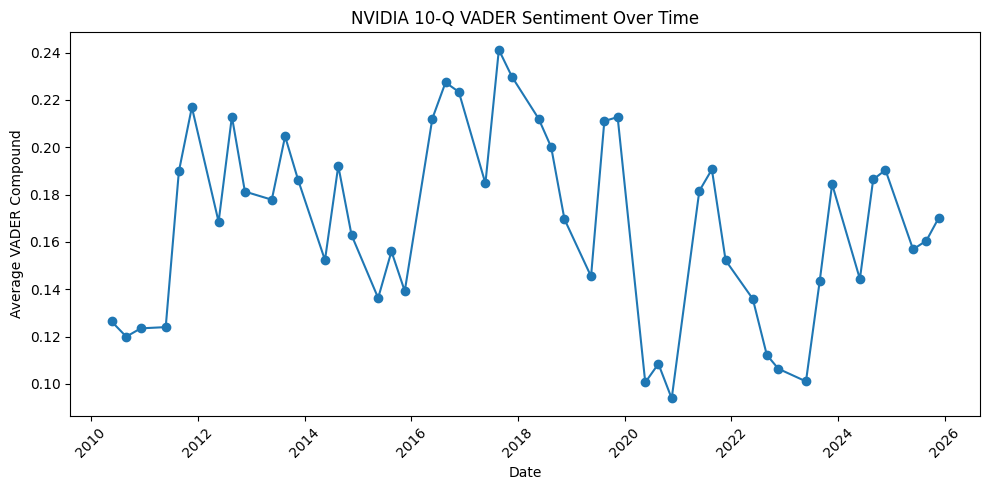

In [664]:
# 10-Q

vader_10q = vader_doc_summary[vader_doc_summary["filing_type"] == "10-Q"].copy()

plt.figure(figsize=(10, 5))
plt.plot(vader_10q["date"], vader_10q["avg_vader_compound"], marker="o")
plt.xlabel("Date")
plt.ylabel("Average VADER Compound")
plt.title("NVIDIA 10-Q VADER Sentiment Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Higher means that document is more positive in tone

TODO: Evaluation using new xlsx